# Notebook 8 – Exploratory Analysis and Visualization

## Objective

Explore whether changes in Pacific food system indicators are associated with changes in metabolic health outcomes across Pacific Island jurisdictions.

This notebook uses the integrated master dataset produced by Notebook 7 to examine regional trends, compare food system and health indicators, and identify preliminary relationships that may support later statistical modeling or dashboard development.

**Input:**

- `observatory_master.csv`

**Main research question:**

Are changes in the Pacific food system associated with changes in obesity, diabetes, and hypertension?

# Section 2. Load the Master Observatory Dataset

## Question

What data are available to investigate the relationship between Pacific food systems and metabolic health?

Load the integrated observatory dataset produced in Notebook 7. This dataset combines metabolic health, food system, and demographic indicators into a single country-year table that serves as the foundation for all subsequent exploratory analyses.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

observatory = pd.read_csv("observatory_master.csv")

print("Master dataset loaded successfully.\n")

print(f"Rows: {len(observatory):,}")
print(f"Columns: {len(observatory.columns)}")

print("\nVariables:")
for column in observatory.columns:
    print(f"• {column}")

display(observatory.head())

Master dataset loaded successfully.

Rows: 720
Columns: 26

Variables:
• ISO3
• Country
• Year
• Underweight_Pct
• HealthyWeight_Pct
• Overweight_Pct
• Obesity_Pct
• Class1_Obesity_Pct
• Class2_Obesity_Pct
• Morbid_Obesity_Pct
• Diabetes_Pct
• Diabetes_Treated_Pct
• Hypertension_Pct
• Hypertension_Diagnosed_Pct
• Hypertension_Treated_Pct
• Hypertension_Controlled_Pct
• Untreated_Stage2_Pct
• Dietary_Energy_kcal
• Fat_g
• Protein_g
• Food_Imports_Export_Value_Pct
• Population
• Population_Thousands
• Population_Density
• Median_Age
• Population_Growth_Rate


,ISO3,Country,Year,Underweight_Pct,HealthyWeight_Pct,Overweight_Pct,Obesity_Pct,Class1_Obesity_Pct,Class2_Obesity_Pct,Morbid_Obesity_Pct,...,Untreated_Stage2_Pct,Dietary_Energy_kcal,Fat_g,Protein_g,Food_Imports_Export_Value_Pct,Population,Population_Thousands,Population_Density,Median_Age,Population_Growth_Rate
0,ASM,American Samoa,1980,0.746896,15.316396,28.330742,54.139611,28.999122,16.019193,9.121296,...,NaN,NaN,NaN,NaN,NaN,32403.0,32.403,162.013,17.832,3.275
1,ASM,American Samoa,1981,0.715825,14.656437,27.924248,55.314224,29.209004,16.534990,9.570230,...,NaN,NaN,NaN,NaN,NaN,33584.0,33.584,167.923,18.047,3.880
2,ASM,American Samoa,1982,0.685943,14.005578,27.496787,56.496159,29.398000,17.060237,10.037922,...,NaN,NaN,NaN,NaN,NaN,34909.0,34.909,174.545,18.234,3.856
3,ASM,American Samoa,1983,0.657359,13.371328,27.054243,57.671857,29.562999,17.589228,10.519631,...,NaN,NaN,NaN,NaN,NaN,36271.0,36.271,181.355,18.422,3.800
4,ASM,American Samoa,1984,0.629968,12.760030,26.599569,58.832065,29.702321,18.117063,11.012682,...,NaN,NaN,NaN,NaN,NaN,37667.0,37.667,188.335,18.613,3.754


# Section 3. Assess Dataset Quality

## Question

Is the integrated observatory dataset complete, internally consistent, and suitable for exploratory analysis?

Before interpreting relationships among variables, verify the structure, temporal coverage, geographic coverage, and completeness of the dataset. This quality assessment identifies any limitations that should be considered during subsequent analyses.

In [ ]:
print("Dataset Summary")
print("-" * 50)

print(f"Rows: {len(observatory):,}")
print(f"Columns: {len(observatory.columns)}")

print("\nStudy period:")
print(f"{observatory['Year'].min()}–{observatory['Year'].max()}")

print("\nJurisdictions:")
print(f"{observatory['Country'].nunique()}")

print(sorted(observatory["Country"].unique()))

print("\nMissing values by variable:")
display(observatory.isna().sum().to_frame("Missing Values"))

print("\nData types:")
display(observatory.dtypes.to_frame("Data Type"))

Dataset Summary
--------------------------------------------------
Rows: 720
Columns: 26

Study period:
1980–2024

Jurisdictions:
16
['American Samoa', 'Cook Islands', 'Federated States of Micronesia', 'Fiji', 'French Polynesia', 'Kiribati', 'Marshall Islands', 'Nauru', 'Niue', 'Palau', 'Samoa', 'Solomon Islands', 'Tokelau', 'Tonga', 'Tuvalu', 'Vanuatu']

Missing values by variable:


,Missing Values
ISO3,0
Country,0
Year,0
Underweight_Pct,0
HealthyWeight_Pct,0
Overweight_Pct,0
Obesity_Pct,0
Class1_Obesity_Pct,0
Class2_Obesity_Pct,0
Morbid_Obesity_Pct,0



Data types:


,Data Type
ISO3,object
Country,object
Year,int64
Underweight_Pct,float64
HealthyWeight_Pct,float64
Overweight_Pct,float64
Obesity_Pct,float64
Class1_Obesity_Pct,float64
Class2_Obesity_Pct,float64
Morbid_Obesity_Pct,float64


# Section 4. Describe the Observatory Variables

## Question

What are the central tendencies and ranges of the metabolic health, food system, and demographic variables?

Descriptive statistics provide an overview of each variable's distribution and help identify differences in scale, variability, and coverage before examining trends and relationships.

In [ ]:
summary_columns = [
    "Obesity_Pct",
    "Diabetes_Pct",
    "Hypertension_Pct",
    "Dietary_Energy_kcal",
    "Fat_g",
    "Protein_g",
    "Food_Imports_Export_Value_Pct",
    "Population",
    "Median_Age"
]

summary = (
    observatory[summary_columns]
    .describe()
    .T
    .round(2)
)

display(summary)

,count,mean,std,min,25%,50%,75%,max
Obesity_Pct,720.0,45.36,17.38,11.14,33.70,44.28,60.55,76.89
Diabetes_Pct,528.0,0.21,0.08,0.07,0.16,0.21,0.28,0.35
Hypertension_Pct,480.0,0.36,0.06,0.23,0.31,0.36,0.39,0.50
Dietary_Energy_kcal,138.0,2783.03,209.19,2307.00,2707.25,2811.50,2892.75,3166.00
Fat_g,136.0,101.84,26.78,46.30,91.25,112.40,121.80,151.90
Protein_g,136.0,80.58,17.25,51.60,71.18,76.15,97.00,131.70
Food_Imports_Export_Value_Pct,238.0,307.11,950.89,4.00,36.25,147.00,256.00,9809.00
Population,704.0,149059.90,219384.41,1552.00,12172.00,59105.00,180453.25,924145.00
Median_Age,704.0,21.61,4.96,13.64,18.55,20.24,23.66,37.84


# Section 5. Regional Trends in Metabolic Health

## Question

How have obesity, diabetes, and hypertension changed across Pacific Island jurisdictions over time?

Regional averages provide an overview of long-term changes in metabolic health and establish the context for examining whether similar changes occurred in the Pacific food system.

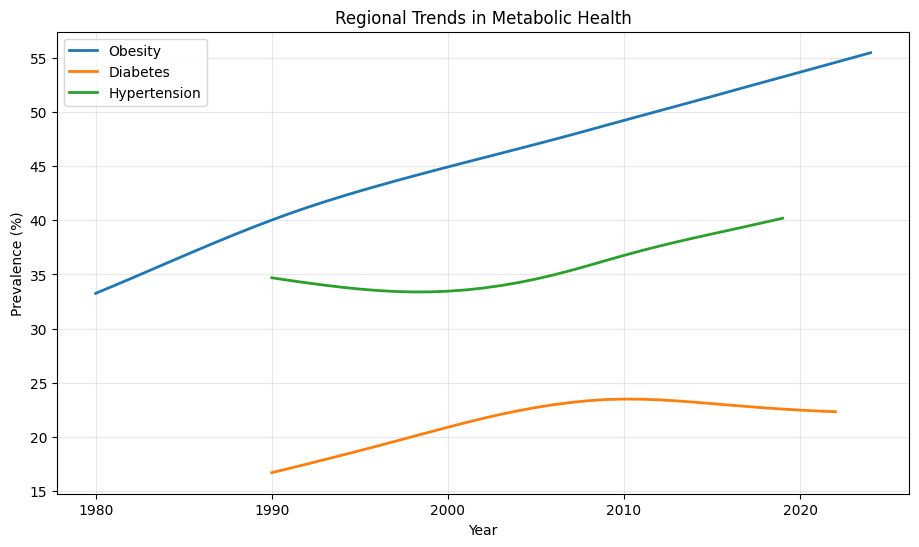

In [ ]:
health_trends = (
    observatory
    .groupby("Year")
    .agg({
        "Obesity_Pct": "mean",
        "Diabetes_Pct": "mean",
        "Hypertension_Pct": "mean"
    })
    .reset_index()
)

plt.figure(figsize=(11,6))

plt.plot(
    health_trends["Year"],
    health_trends["Obesity_Pct"],
    linewidth=2,
    label="Obesity"
)

diabetes = health_trends.dropna(subset=["Diabetes_Pct"])
plt.plot(
    diabetes["Year"],
    diabetes["Diabetes_Pct"] * 100,
    linewidth=2,
    label="Diabetes"
)

hypertension = health_trends.dropna(subset=["Hypertension_Pct"])
plt.plot(
    hypertension["Year"],
    hypertension["Hypertension_Pct"] * 100,
    linewidth=2,
    label="Hypertension"
)

plt.title("Regional Trends in Metabolic Health")
plt.xlabel("Year")
plt.ylabel("Prevalence (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Section 6. Define the Nutrition Transition Analysis Period

## Question

What period contains overlapping food system and metabolic health data?

To evaluate relationships between food system indicators and metabolic health, subsequent analyses are limited to years in which food system observations are available. This creates a consistent analytical dataset for all remaining figures and statistical summaries.

In [ ]:
food_columns = [
    "Dietary_Energy_kcal",
    "Fat_g",
    "Protein_g",
    "Food_Imports_Export_Value_Pct"
]

transition_data = observatory.dropna(
    subset=food_columns,
    how="all"
).copy()

print("Analysis subset created.\n")

print(f"Rows: {len(analysis)}")

print(f"Countries: {analysis['Country'].nunique()}")

print(
    f"Years: {analysis['Year'].min()}–{analysis['Year'].max()}"
)

Analysis subset created.

Rows: 248
Countries: 13
Years: 2001–2023


# Section 7. Explore Relationships Between Food System and Metabolic Health

## Question

Which food system indicators appear to be most strongly associated with metabolic health outcomes?

A correlation matrix provides an initial overview of linear relationships among the available food system and metabolic health variables. These correlations are exploratory and should not be interpreted as evidence of causation.

In [ ]:
correlation_data = transition_data[
    [
        "Obesity_Pct",
        "Diabetes_Pct",
        "Hypertension_Pct",
        "Dietary_Energy_kcal",
        "Fat_g",
        "Protein_g",
        "Food_Imports_Export_Value_Pct"
    ]
].copy()

# Convert proportions to percentages for easier interpretation.
correlation_data["Diabetes_Pct"] *= 100
correlation_data["Hypertension_Pct"] *= 100

correlation_matrix = correlation_data.corr().round(2)

print("Correlation Matrix")

display(correlation_matrix)

Correlation Matrix


,Obesity_Pct,Diabetes_Pct,Hypertension_Pct,Dietary_Energy_kcal,Fat_g,Protein_g,Food_Imports_Export_Value_Pct
Obesity_Pct,1.00,0.65,0.57,0.70,0.65,0.80,0.19
Diabetes_Pct,0.65,1.00,0.42,0.78,0.62,0.42,-0.08
Hypertension_Pct,0.57,0.42,1.00,0.71,0.74,0.73,0.36
Dietary_Energy_kcal,0.70,0.78,0.71,1.00,0.84,0.63,0.64
Fat_g,0.65,0.62,0.74,0.84,1.00,0.69,0.11
Protein_g,0.80,0.42,0.73,0.63,0.69,1.00,0.17
Food_Imports_Export_Value_Pct,0.19,-0.08,0.36,0.64,0.11,0.17,1.00


# Section 8. Exploratory Relationships Between Food System Indicators and Metabolic Health

## Question

Which food system indicators appear most strongly associated with metabolic health across Pacific Island jurisdictions?

Each jurisdiction is represented by its average values during the common analysis period (2001–2023). A simple linear regression line and Pearson correlation coefficient are included to summarize the direction and strength of each observed relationship. These exploratory visualizations are intended to identify patterns that may warrant more formal statistical analysis in subsequent work.

In [ ]:
from scipy.stats import pearsonr

country_summary = (
    transition_data
    .groupby("Country")
    .agg({
        "Dietary_Energy_kcal":"mean",
        "Fat_g":"mean",
        "Protein_g":"mean",
        "Food_Imports_Export_Value_Pct":"mean",
        "Obesity_Pct":"mean",
        "Diabetes_Pct":"mean",
        "Hypertension_Pct":"mean"
    })
    .reset_index()
)

country_summary["Diabetes_Pct"] *= 100
country_summary["Hypertension_Pct"] *= 100

print("Country summaries created.")
print("Countries:", len(country_summary))

display(country_summary.round(2))

Country summaries created.
Countries: 13


,Country,Dietary_Energy_kcal,Fat_g,Protein_g,Food_Imports_Export_Value_Pct,Obesity_Pct,Diabetes_Pct,Hypertension_Pct
0,Cook Islands,NaN,NaN,NaN,339.32,64.18,28.88,41.29
1,Federated States of Micronesia,NaN,116.65,76.40,NaN,47.99,32.91,NaN
2,Fiji,2808.78,87.13,74.66,31.00,30.82,19.88,35.11
3,French Polynesia,2804.22,118.60,101.67,219.73,44.47,16.01,39.11
4,Kiribati,2989.04,115.59,76.18,232.86,43.39,22.47,35.01
5,Marshall Islands,NaN,147.80,109.40,NaN,43.13,30.26,NaN
6,Nauru,NaN,124.65,110.45,28.73,69.28,27.83,37.99
7,Niue,NaN,NaN,NaN,261.06,61.71,24.12,35.73
8,Samoa,2932.83,122.41,91.79,199.41,57.53,16.83,34.70
9,Solomon Islands,2394.74,49.45,57.18,27.68,19.18,7.64,25.83


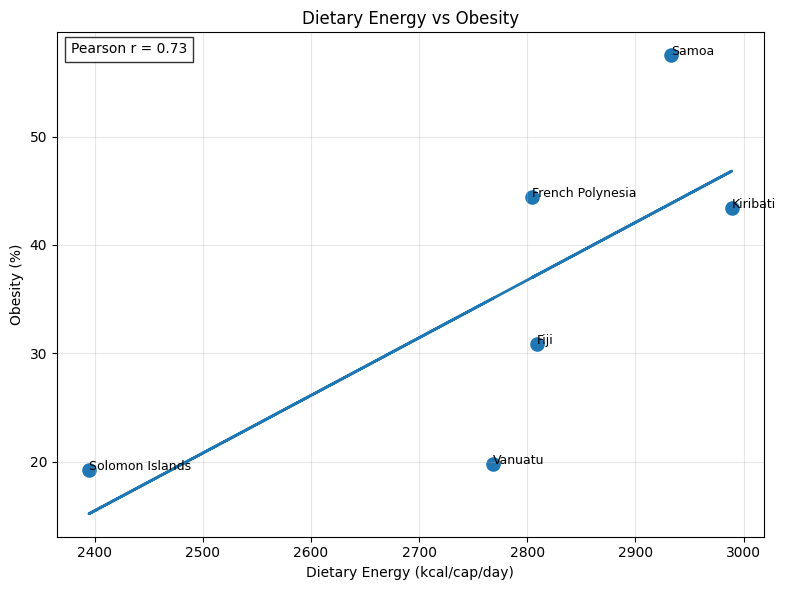

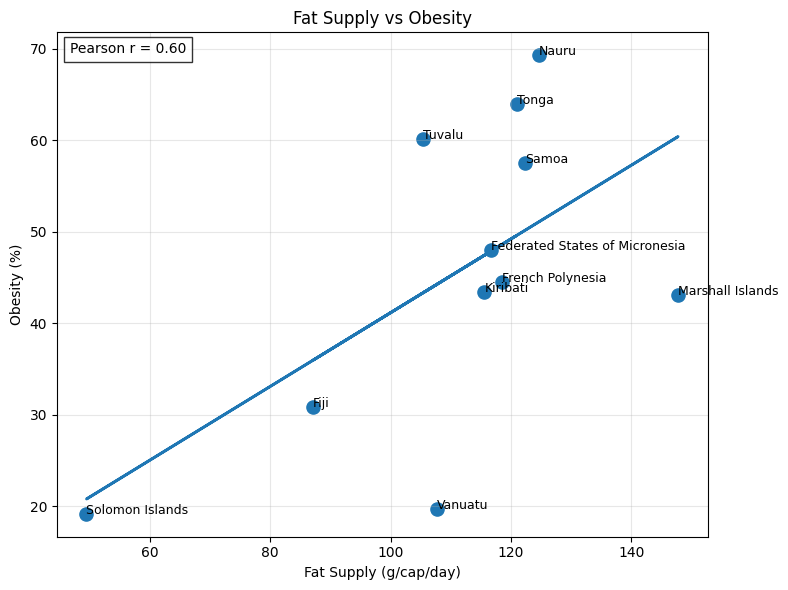

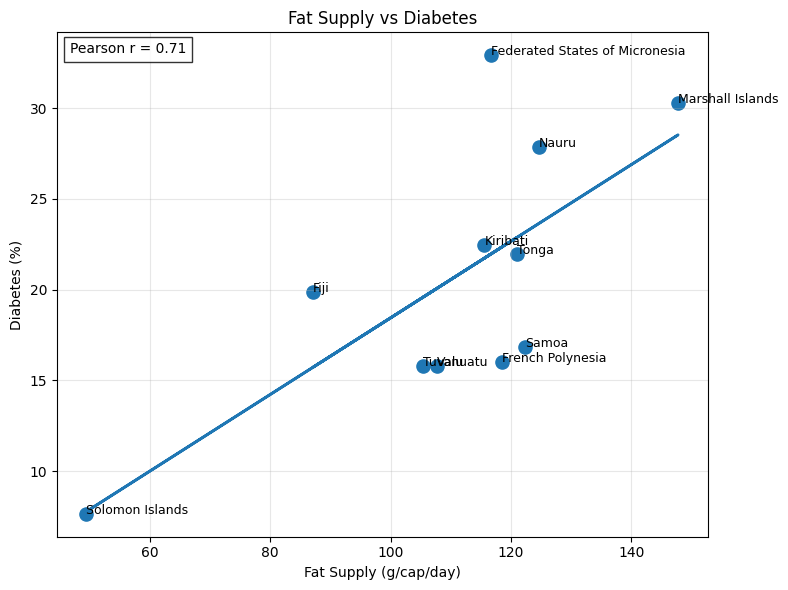

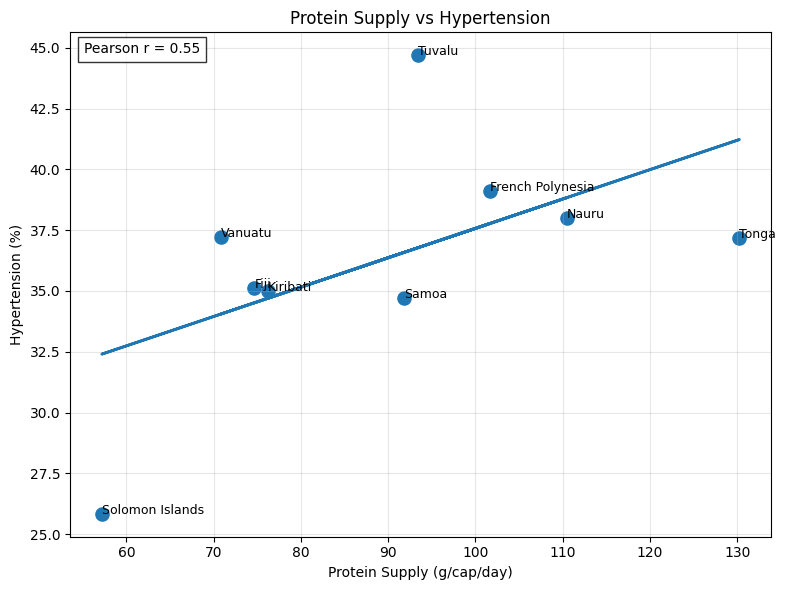

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plots = [
    (
        "Dietary_Energy_kcal",
        "Obesity_Pct",
        "Dietary Energy vs Obesity",
        "Dietary Energy (kcal/cap/day)",
        "Obesity (%)"
    ),
    (
        "Fat_g",
        "Obesity_Pct",
        "Fat Supply vs Obesity",
        "Fat Supply (g/cap/day)",
        "Obesity (%)"
    ),
    (
        "Fat_g",
        "Diabetes_Pct",
        "Fat Supply vs Diabetes",
        "Fat Supply (g/cap/day)",
        "Diabetes (%)"
    ),
    (
        "Protein_g",
        "Hypertension_Pct",
        "Protein Supply vs Hypertension",
        "Protein Supply (g/cap/day)",
        "Hypertension (%)"
    )
]

for x, y, title, xlabel, ylabel in plots:
    subset = country_summary[[x, y, "Country"]].dropna().copy()

    r, p = pearsonr(subset[x], subset[y])

    plt.figure(figsize=(8, 6))

    plt.scatter(
        subset[x],
        subset[y],
        s=90
    )

    m, b = np.polyfit(subset[x], subset[y], 1)

    plt.plot(
        subset[x],
        m * subset[x] + b,
        linewidth=2
    )

    for _, row in subset.iterrows():
        plt.text(
            row[x],
            row[y],
            row["Country"],
            fontsize=9
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)

    plt.text(
        0.02,
        0.98,
        f"Pearson r = {r:.2f}",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.show()

# Section 9. Correlation Analysis

## Question

Which food system indicators show the strongest linear association with obesity, diabetes, and hypertension?

Pearson correlation coefficients (r) are calculated for every combination of food system indicator and metabolic health outcome using the common analysis dataset (2001–2023).

Correlation values range from -1 to +1.

- Positive values indicate both variables tend to increase together.
- Negative values indicate one variable tends to decrease as the other increases.
- Values near zero indicate little or no linear association.

These correlations are descriptive and do not imply causation.

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

food_variables = {
    "Dietary_Energy_kcal": "Dietary Energy",
    "Fat_g": "Fat Supply",
    "Protein_g": "Protein Supply",
    "Food_Imports_Export_Value_Pct": "Food Import Dependence"
}

health_variables = {
    "Obesity_Pct": ("Obesity", 1),
    "Diabetes_Pct": ("Diabetes", 100),
    "Hypertension_Pct": ("Hypertension", 100)
}

results = []

for food_col, food_label in food_variables.items():
    for health_col, (health_label, multiplier) in health_variables.items():

        subset = transition_data[[food_col, health_col]].dropna().copy()
        subset[health_col] = subset[health_col] * multiplier

        r, p = pearsonr(subset[food_col], subset[health_col])

        results.append({
            "Food Indicator": food_label,
            "Health Outcome": health_label,
            "Pearson r": round(r, 3),
            "p-value": round(p, 4),
            "Observations": len(subset)
        })

correlations = (
    pd.DataFrame(results)
    .sort_values(
        by="Pearson r",
        key=lambda s: s.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

display(correlations)

,Food Indicator,Health Outcome,Pearson r,p-value,Observations
0,Protein Supply,Obesity,0.798,0.0000,136
1,Dietary Energy,Diabetes,0.777,0.0000,132
2,Fat Supply,Hypertension,0.743,0.0000,114
3,Protein Supply,Hypertension,0.725,0.0000,114
4,Dietary Energy,Hypertension,0.705,0.0000,114
5,Dietary Energy,Obesity,0.697,0.0000,138
6,Fat Supply,Obesity,0.648,0.0000,136
7,Fat Supply,Diabetes,0.625,0.0000,136
8,Protein Supply,Diabetes,0.416,0.0000,136
9,Food Import Dependence,Hypertension,0.359,0.0000,205


# Section 10. Correlation Heatmap

## Question

Which food system indicators show the strongest overall association with metabolic health outcomes?

A heatmap summarizes all food system and metabolic health correlations in a single figure. This makes it easier to compare patterns across obesity, diabetes, and hypertension without relying on multiple separate scatterplots.

Health Outcome,Diabetes,Hypertension,Obesity
Food Indicator,,,
Dietary Energy,0.777,0.705,0.697
Fat Supply,0.625,0.743,0.648
Food Import Dependence,-0.082,0.359,0.188
Protein Supply,0.416,0.725,0.798


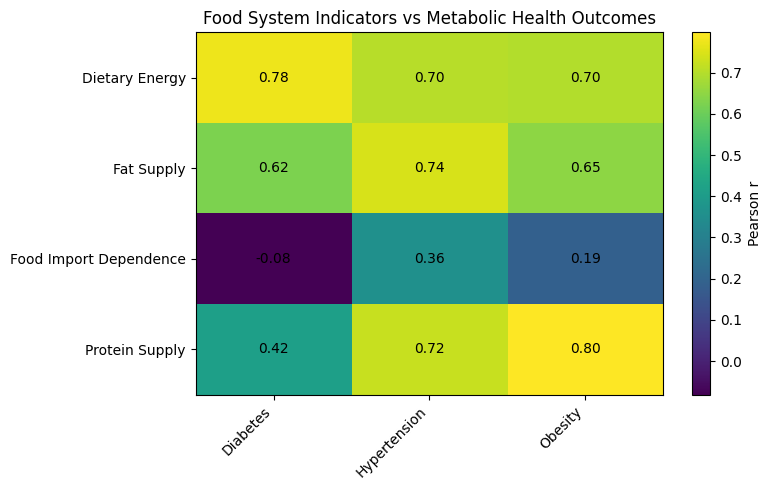

In [ ]:
heatmap_data = correlations.pivot(
    index="Food Indicator",
    columns="Health Outcome",
    values="Pearson r"
)

display(heatmap_data)

plt.figure(figsize=(8, 5))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Pearson r")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.title("Food System Indicators vs Metabolic Health Outcomes")
plt.tight_layout()
plt.show()

# Section 11. Key Findings and Interpretation

The exploratory analysis suggests that food availability indicators are more strongly associated with metabolic health outcomes than the food import dependence indicator.

Among the pairwise correlations, protein supply showed the strongest association with obesity (r = 0.798), while dietary energy showed the strongest association with diabetes (r = 0.777), and fat supply showed the strongest association with hypertension (r = 0.743). Dietary energy, fat supply, and protein supply all showed moderate to strong positive associations with at least one metabolic health outcome.

Food import dependence showed weaker and less consistent associations. It was modestly associated with hypertension (r = 0.359), weakly associated with obesity (r = 0.188), and slightly negatively associated with diabetes (r = -0.082). This suggests that the economic import-dependence measure may not capture dietary exposure as directly as food availability indicators.

These results should be interpreted cautiously. Correlations do not establish causation, and the analysis is ecological, meaning it compares country-level averages rather than individual-level diet and health outcomes. The observed associations may also reflect unmeasured factors such as income, urbanization, physical activity, healthcare access, age structure, food quality, or historical differences among jurisdictions.

Overall, the exploratory analysis supports the value of the Pacific Nutrition Transition Observatory as a tool for identifying food system and metabolic health patterns that warrant deeper statistical modeling.

# Notebook Summary

This notebook performed an exploratory analysis of the Pacific Nutrition Transition Observatory by integrating food system, metabolic health, and demographic indicators across Pacific Island jurisdictions.

Quality assurance confirmed that the integrated dataset was suitable for exploratory analysis, while also documenting differences in temporal coverage among the source datasets. A common analysis period (2001–2023) was established to ensure that food system and metabolic health variables were compared consistently.

Exploratory visualizations and correlation analyses identified several moderate to strong positive associations between food availability indicators and metabolic health outcomes. Dietary energy, fat supply, and protein supply demonstrated stronger associations with obesity, diabetes, and hypertension than the food import dependence indicator. These findings suggest that measures of food availability may better characterize the nutrition transition than economic measures of food import dependence alone.

Because this analysis is ecological and observational, the results should be interpreted as hypothesis-generating rather than causal. The integrated observatory developed in this project provides a reproducible foundation for subsequent statistical modeling, country-level comparisons, and interactive visualization.

# Section 12. Export Master Observatory Dataset

The final integrated observatory dataset is exported for use in downstream notebooks.

This dataset serves as the canonical data source for the Interactive Pacific Nutrition Transition Explorer (Notebook 9) and any future analyses built from this project.

In [39]:
import os

os.makedirs("processed_data", exist_ok=True)

observatory.to_csv(
    "processed_data/pacific_nutrition_transition_observatory.csv",
    index=False
)

print("Master dataset exported successfully.")
print(f"Rows: {observatory.shape[0]}")
print(f"Columns: {observatory.shape[1]}")
print("\nSaved to:")
print("processed_data/pacific_nutrition_transition_observatory.csv")

Master dataset exported successfully.
Rows: 720
Columns: 26

Saved to:
processed_data/pacific_nutrition_transition_observatory.csv
